In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)

# Liệt kê toàn bộ file trong thư mục
for root, dirs, files in os.walk(path):
    for file in files:
        full_path = os.path.join(root, file)
        size = os.path.getsize(full_path)
        print(f"{full_path}  ({size:,} bytes)")

100%|██████████| 22.0M/22.0M [00:01<00:00, 20.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/t10k-images.idx3-ubyte  (7,840,016 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/t10k-labels.idx1-ubyte  (10,008 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/train-labels.idx1-ubyte  (60,008 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/train-images.idx3-ubyte  (47,040,016 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte  (10,008 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/train-labels-idx1-ubyte/train-labels-idx1-ubyte  (60,008 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/train-images-idx3-ubyte/train-images-idx3-ubyte  (47,040,016 bytes)
/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/t10k-images-idx3-ubyte/t10k-image

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.optimizers import Adam
from sklearn.metrics import classification_report

In [3]:
# File .idx là binary format — cần đọc thủ công
# Cấu trúc: 4 byte magic number, 4 byte số lượng, rồi dữ liệu

def read_idx_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def read_idx_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [4]:
path = "/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1"

X_train = read_idx_images(f"{path}/train-images.idx3-ubyte")
y_train = read_idx_labels(f"{path}/train-labels.idx1-ubyte")
X_test  = read_idx_images(f"{path}/t10k-images.idx3-ubyte")
y_test  = read_idx_labels(f"{path}/t10k-labels.idx1-ubyte")

print("X_train shape:", X_train.shape)   # (60000, 28, 28)
print("y_train shape:", y_train.shape)   # (60000,)
print("X_test shape :", X_test.shape)    # (10000, 28, 28)
print("y_test shape :", y_test.shape)    # (10000,)
print("Các nhãn:", np.unique(y_train))   # [0 1 2 3 4 5 6 7 8 9]

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)
Các nhãn: [0 1 2 3 4 5 6 7 8 9]


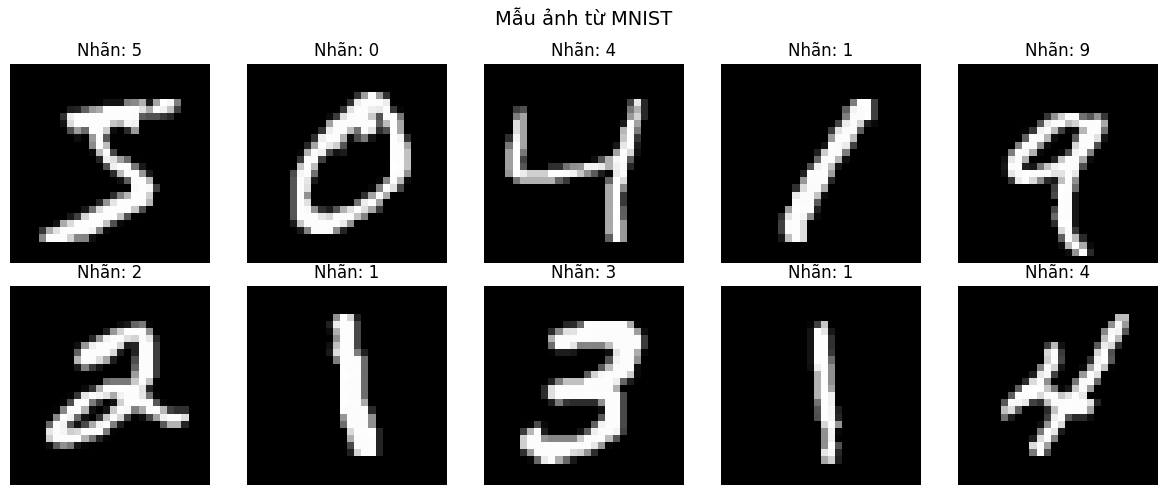

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f"Nhãn: {y_train[i]}")
    axes[i].axis('off')

plt.suptitle("Mẫu ảnh từ MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Flatten 28x28 => 784, chuẩn hóa về [0,1]
X_train_flat = X_train.reshape(60000, 784).astype('float32') / 255.0
X_test_flat  = X_test.reshape(10000, 784).astype('float32') / 255.0

print("X_train sau xử lý:", X_train_flat.shape)
print("Giá trị min/max:", X_train_flat.min(), "/", X_train_flat.max())

X_train sau xử lý: (60000, 784)
Giá trị min/max: 0.0 / 1.0


In [7]:
# MNIST grayscale 28x28 đơn giản hơn CIFAR10 nhiều
# Không cần mạng quá lớn, tránh overfit
model = Sequential()

model.add(Dense(units=512,
                input_dim=784,
                kernel_initializer='he_uniform',
                activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=256,
                kernel_initializer='he_uniform',
                activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=128,
                kernel_initializer='he_uniform',
                activation='relu'))
model.add(Dropout(0.2))

# Output 10 lớp (số 0-9)
model.add(Dense(units=10, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [8]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1)

model_fit = model.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.8914 - loss: 0.3503 - val_accuracy: 0.9690 - val_loss: 0.1048 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9501 - loss: 0.1631 - val_accuracy: 0.9737 - val_loss: 0.0843 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9618 - loss: 0.1243 - val_accuracy: 0.9787 - val_loss: 0.0694 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9695 - loss: 0.1005 - val_accuracy: 0.9802 - val_loss: 0.0704 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9720 - loss: 0.0900 - val_accuracy: 0.9792 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9753 - loss: 0.0778 - val_accuracy: 0.9803 - val_loss: 0.0618 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9775 - l

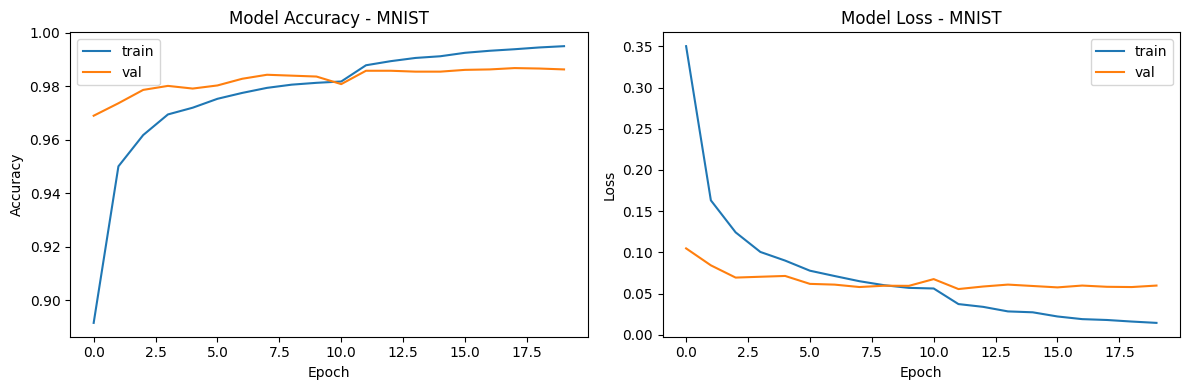


Test accuracy: 0.9845
Test loss    : 0.0496


In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'],     label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Model Accuracy - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'],     label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Model Loss - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss    : {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



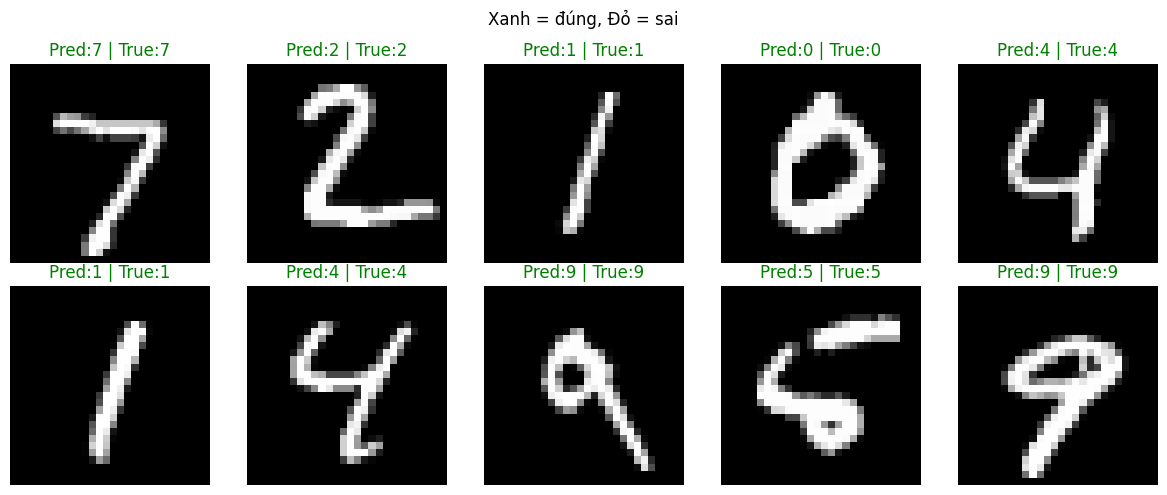

In [10]:
class_names = [str(i) for i in range(10)]

y_pred = np.argmax(model.predict(X_test_flat), axis=1)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Xem vài ảnh dự báo
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    axes[i].set_title(f"Pred:{y_pred[i]} | True:{y_test[i]}", color=color)
    axes[i].axis('off')
plt.suptitle("Xanh = đúng, Đỏ = sai", fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Chạy block này và gửi output
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss    : {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test_flat), axis=1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.9845
Test loss    : 0.0496
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

